## Problem Statement

The goal of this project is to build a machine learning model that can automatically classify SMS messages as spam or not spam (ham).

This is a supervised machine learning problem where the model learns from labeled data to identify patterns in text messages and predict whether a new message is spam or legitimate.

Type: Classification Problem (Binary Classification)

In [87]:
import pandas as pd

## DATASET

In [88]:
df = pd.read_csv('spam.csv', encoding='latin-1')

## EDA

In [89]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [90]:
df = df[['v1', 'v2']]
df.columns = ['label','message']


In [91]:
df.drop_duplicates(inplace=True)
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5169 non-null   object
 1   message  5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


- No missing value.

In [93]:
df.describe()

,label,message
count,5169,5169
unique,2,5169
top,ham,"Go until jurong point, crazy.. Available only ..."
freq,4516,1


In [94]:
df['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

OBSERVATION
- Dataset is imbalanced(more ham than spam)

In [95]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [96]:
df['message_length'] = df['message'].apply(len)

In [97]:
df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


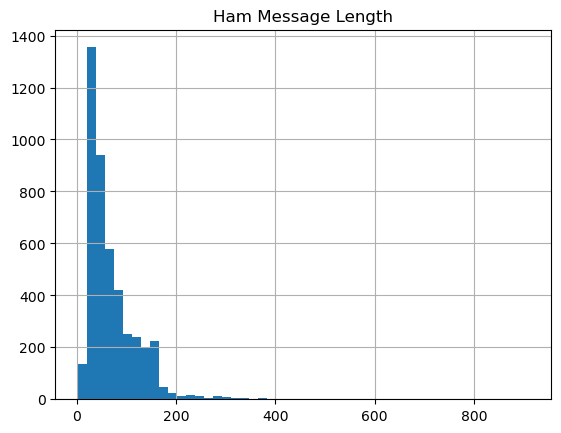

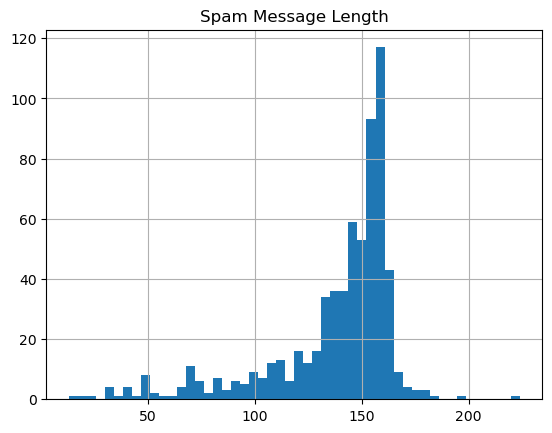

In [98]:
import matplotlib.pyplot as plt

df[df['label'] == 0]['message_length'].hist(bins=50)
plt.title("Ham Message Length")
plt.show()

df[df['label'] == 1]['message_length'].hist(bins=50)
plt.title("Spam Message Length")
plt.show()

- X-axis represents message length
- Y-axis represents the frequency (number of messages)

Spam messages are longer than ham messages

Message length can help in classification

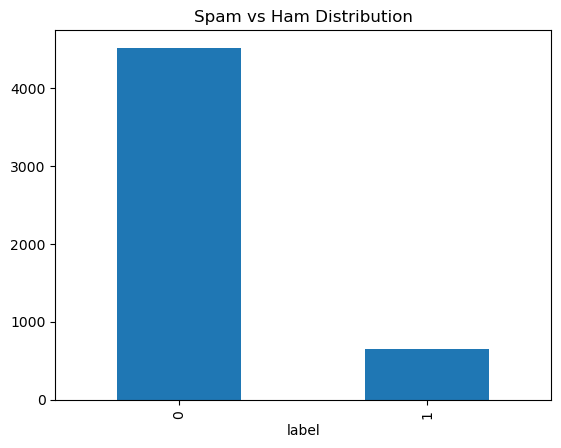

In [99]:
df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Distribution")
plt.show()

## TEXT PREPROCESSING

In [100]:
import string
import nltk
from nltk.corpus import stopwords

In [101]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\divya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [102]:
def preprocess_text(text):
    #convert to lowercase
    text = text.lower()

    #remove punctuations
    text = ''.join([char for char in text if char not in string.punctuation])

    #remove stopwards
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [103]:
df['cleaned_message'] = df['message'].apply(preprocess_text)

In [104]:
df[['message', 'cleaned_message']].head()

,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## FEATURE EXTRACTION

- Used TF-IDF Vectorization to convert text into numerical features
- Important words are given higher weight
- Converted cleaned text into a matrix of numerical features

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['cleaned_message'])
y = df['label']

## MODELLING

## Naive Bayes

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [108]:
y_pred = model.predict(X_test)

## MODEL EVALUATION

In [109]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.960348162475822

In [110]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[903,   0],
       [ 41,  90]], dtype=int64)

In [111]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       1.00      0.69      0.81       131

    accuracy                           0.96      1034
   macro avg       0.98      0.84      0.90      1034
weighted avg       0.96      0.96      0.96      1034



### Model Evaluation (Naive Bayes)

- The model achieved high accuracy (~96.7%)
- Spam precision is 1.00, meaning all predicted spam messages are correct
- Spam recall is 0.77, meaning some spam messages are missed
- The model is conservative in predicting spam, reducing false positives but missing some spam

## Logistic Regression

In [112]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


## MODEL EVALUATION

In [113]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       903
           1       0.99      0.53      0.69       131

    accuracy                           0.94      1034
   macro avg       0.96      0.77      0.83      1034
weighted avg       0.94      0.94      0.93      1034



## SVM

In [114]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [115]:

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       903
           1       0.99      0.81      0.89       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.98      0.97      0.97      1034



### Model Comparison

- Compared Naive Bayes, Logistic Regression, and Support Vector Machine (SVM)
- SVM achieved the highest accuracy (~98%) and best balance between precision and recall
- Naive Bayes had perfect precision but lower recall
- Logistic Regression performed the weakest among the three

### Final Model Selection

- Support Vector Machine (SVM) was selected as the final model due to its superior overall performance